In [1]:
import os
import math
import numpy as np
import xarray as xr
import scipy.ndimage
from pathlib import Path
import netCDF4 as nc
import cc3d
import gc
import metpy
from metpy.calc import density
from metpy.units import units
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import LogNorm
import matplotlib.patches as mpatches

#Output
output_dir = Path("/mnt/stor-pool-01/projects/heus/ShellAnalysis/full-area")
output_dir.mkdir(parents=True, exist_ok=True)

#Constants
L_v = 2.5 * (10**6) #latent heat
c_pd = 1004 #specific heat
p_0 = 10**5 #reference pressure
R_d = 287
R_v = 461.5
negative_w_threshold = -0.25
t=6


In [2]:
#Open datasets
ds_p = xr.open_dataset("/mnt/stor-pool-01/projects/heus/EUREC4A_Eulerian/Feb_1st_12day_cdnc70_nudge/p.nc", decode_times=False,chunks={'time': 1}) #pressure
ds_ql = xr.open_dataset("/mnt/stor-pool-01/projects/heus/EUREC4A_Eulerian/Feb_1st_12day_cdnc70_nudge/ql.nc", decode_times=False,chunks={'time': 1}) #liquid water mixing ratio
ds_qt = xr.open_dataset("/mnt/stor-pool-01/projects/heus/EUREC4A_Eulerian/Feb_1st_12day_cdnc70_nudge/qt.nc", decode_times=False,chunks={'time': 1}) #water mixing ratio
ds_th_l = xr.open_dataset("/mnt/stor-pool-01/projects/heus/EUREC4A_Eulerian/Feb_1st_12day_cdnc70_nudge/thl.nc", decode_times=False,chunks={'time': 1}) #liquid virtual potential temperature
ds_w = xr.open_dataset("/mnt/stor-pool-01/projects/heus/EUREC4A_Eulerian/Feb_1st_12day_cdnc70_nudge/w.nc", decode_times=False,chunks={'time': 1}).rename({'zh':'z'}).interp(z=ds_ql.z)
#ds_shell_depth = xr.open_dataset("/mnt/stor-pool-01/projects/heus/ShellAnalysis/full-area/shell_depth.nc", decode_times=False,chunks={'time': 1})
ds_shell_file = xr.open_dataset("/mnt/stor-pool-01/projects/heus/ShellAnalysis/full-area/shell_mask.nc", decode_times=False, chunks={'time': 1})
ds_shell_mask = ds_shell_file["shell_mask"].astype(bool)

/mnt/stor-pool-01/users/2821011/.local/lib/python3.9/site-packages/xarray/core/dataset.py:277: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(


In [3]:
#Calculate VPG
ds_vpg = ds_p.p.differentiate("z").to_dataset(name="vpg")

In [4]:
#Calculate B
chi = R_d / c_pd
big_pi = (ds_p.p / p_0) ** chi
ds_thv = (ds_th_l.thl + (L_v / (c_pd * big_pi)) * ds_ql.ql) * (1 - (1 - (R_v / R_d)) - ((R_v / R_d) * ds_qt.qt))
thv_mean = ds_thv.mean(dim=['y', 'x'], skipna=True)
da_b = (9.81/300) * (ds_thv - thv_mean)

/mnt/stor-pool-01/users/2821011/.local/lib/python3.9/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in power
  return func(*(_execute_task(a, cache) for a in args))
/mnt/stor-pool-01/users/2821011/.local/lib/python3.9/site-packages/dask/core.py:127: RuntimeWarning: divide by zero encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/mnt/stor-pool-01/users/2821011/.local/lib/python3.9/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in multiply
  return func(*(_execute_task(a, cache) for a in args))


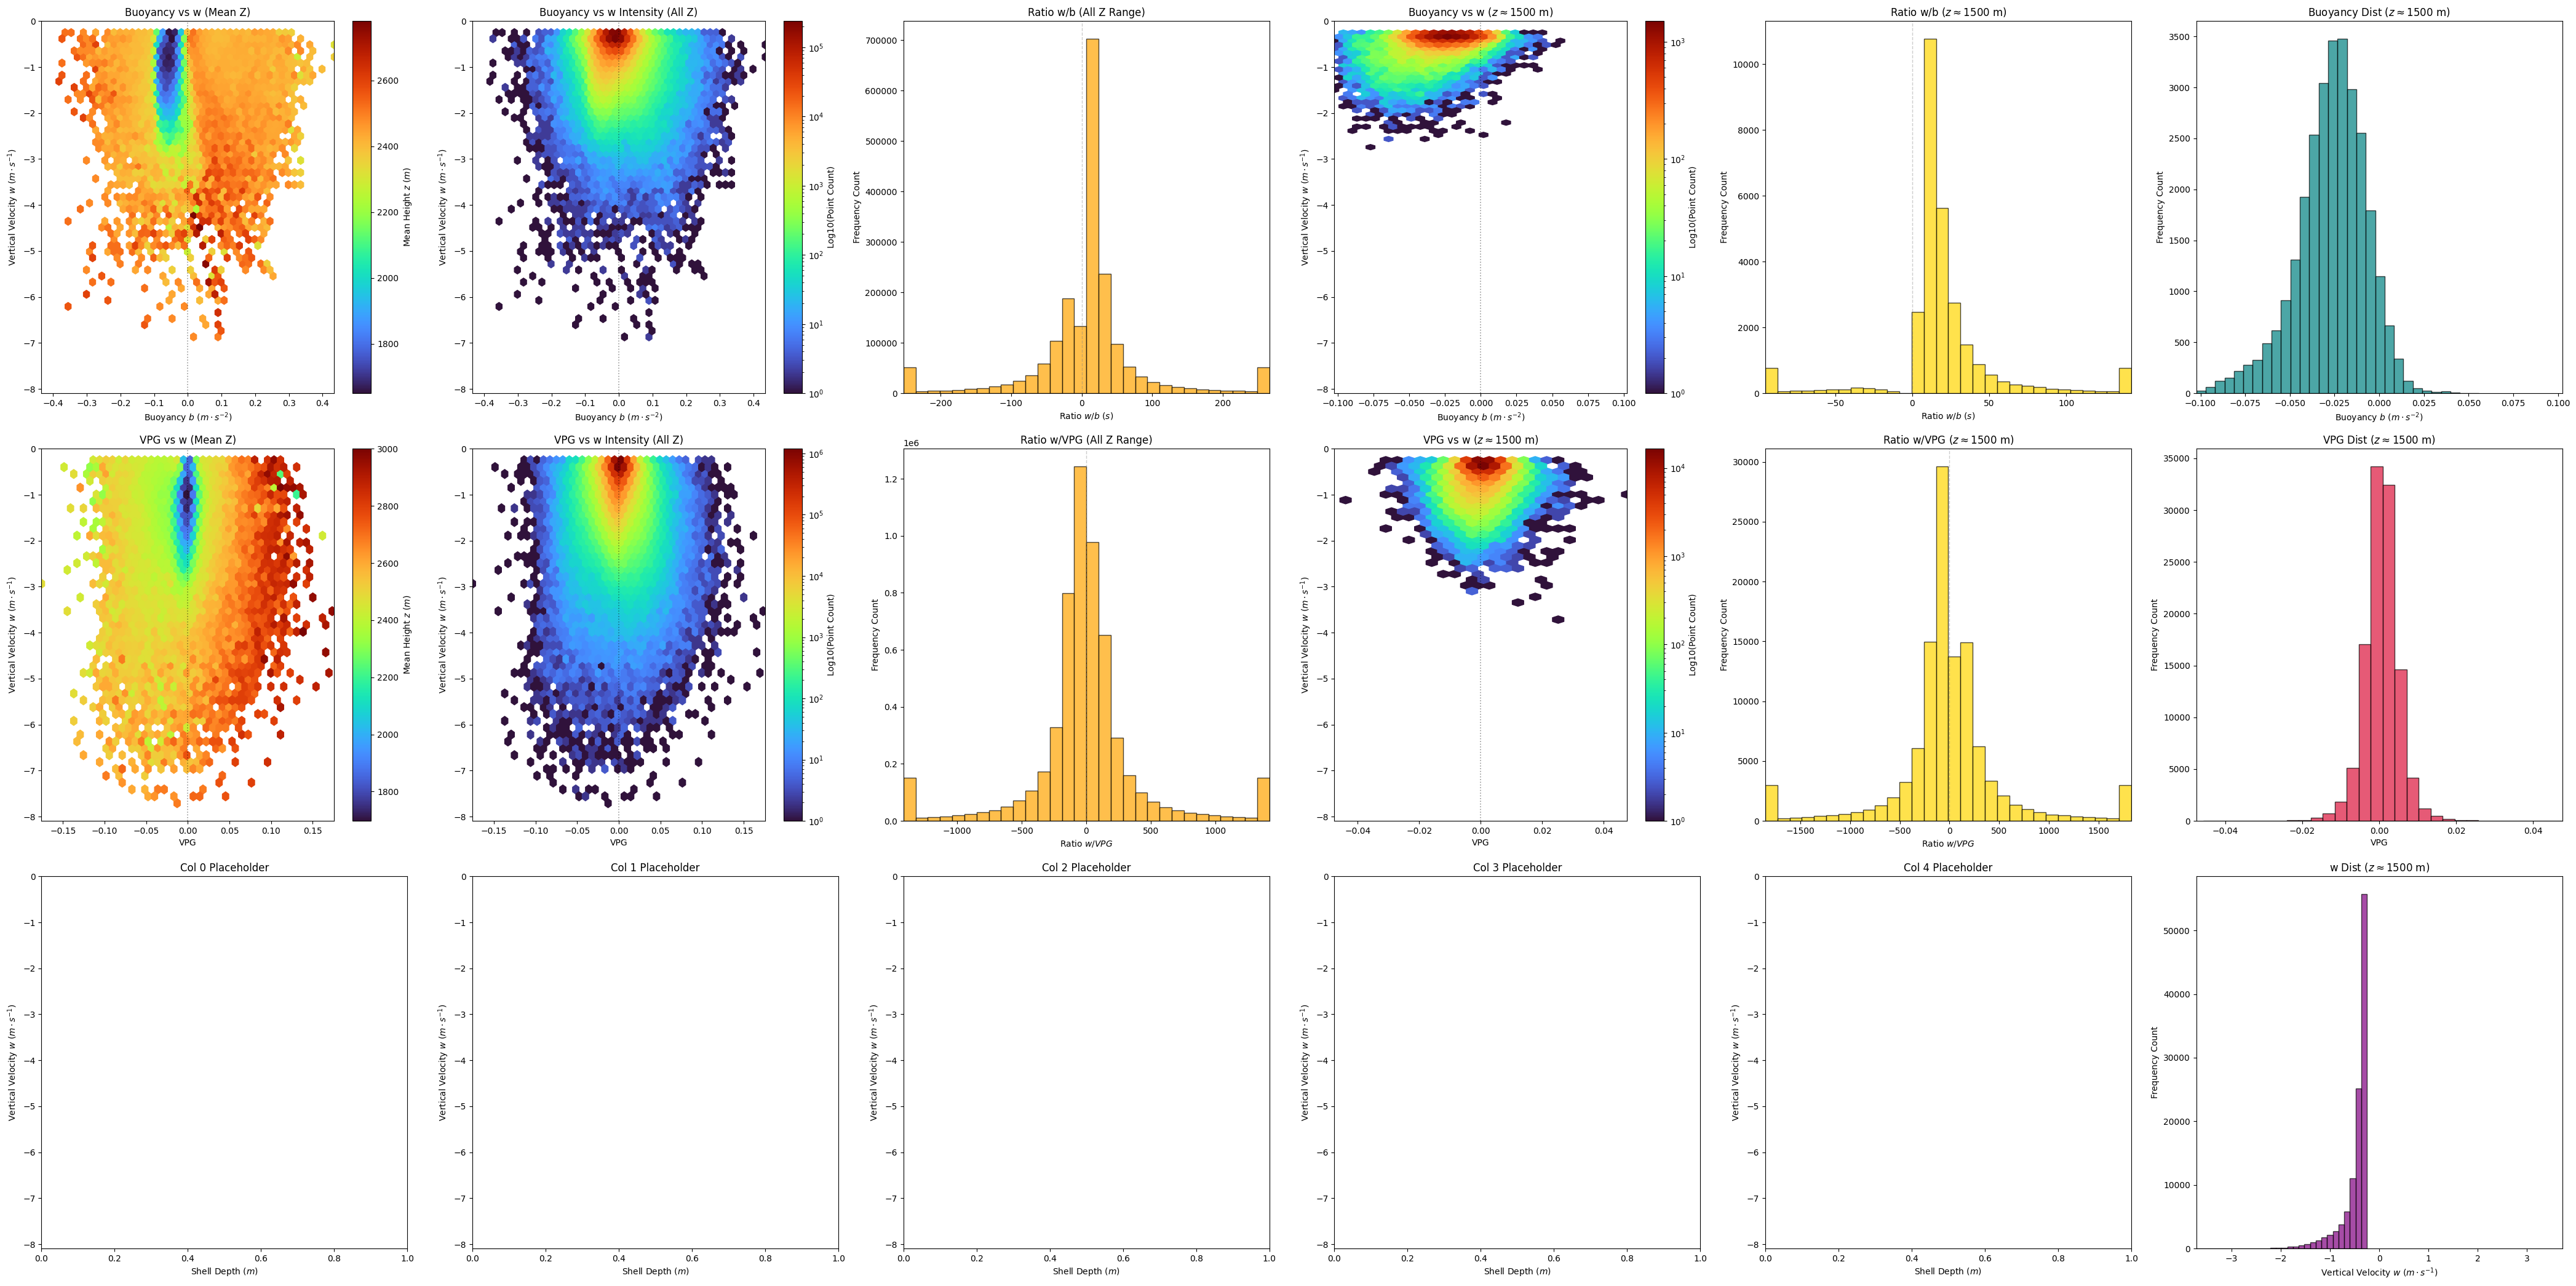

/mnt/stor-pool-01/users/2821011/.local/lib/python3.9/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in power
  return func(*(_execute_task(a, cache) for a in args))
/mnt/stor-pool-01/users/2821011/.local/lib/python3.9/site-packages/dask/core.py:127: RuntimeWarning: divide by zero encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/mnt/stor-pool-01/users/2821011/.local/lib/python3.9/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in multiply
  return func(*(_execute_task(a, cache) for a in args))
/mnt/stor-pool-01/users/2821011/.local/lib/python3.9/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in power
  return func(*(_execute_task(a, cache) for a in args))
/mnt/stor-pool-01/users/2821011/.local/lib/python3.9/site-packages/dask/core.py:127: RuntimeWarning: divide by zero encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/mnt/stor-pool-01/users/2821011/.

In [ ]:
# =====================================================================
# 1. DATASETS SETUP & ALIGNMENT
# =====================================================================
ds_plot = xr.merge([da_b.to_dataset(name="b"), ds_w, ds_vpg])
ds_plot = ds_plot.set_index(z="z")

# 2. Extract a specific time slice and apply your outline restriction mask
profile_full_height = ds_plot.isel(time=t)
mask_slice = ds_shell_mask.isel(time=t)
profile_shell = profile_full_height.where(mask_slice)

# 3. Filter down to the broad vertical scaling region and compute into memory
profile_restricted = profile_shell.sel(z=slice(1000.0, 3000.0))
profile_physical = profile_restricted.compute()

# 4. CHOOSE TARGET ALTITUDE: Extract the physical 2D plane for this specific level
target_z = 1500.0
slice_2d = profile_physical.sel(z=target_z, method="nearest")


# =====================================================================
# 5. COORDINATE GRIDS & EXTRACTION (ALL DOT-NOTATIONS REMOVED)
# =====================================================================
# 'z' is a coordinate array, but we access it via string bracket for safety
b_3d, z_3d = xr.broadcast(profile_physical["b"], profile_physical["z"])

# Separate 1D data point pools by dropping non-shell (NaN) array padding
w_all_values = profile_physical["w"].values
nan_mask_all = ~np.isnan(w_all_values)

b_points = profile_physical["b"].values[nan_mask_all]
w_points = w_all_values[nan_mask_all]
p_points = profile_physical["vpg"].values[nan_mask_all]  # Using your verified 'vpg' variable name
z_points = z_3d.values[nan_mask_all]

w_slice_values = slice_2d["w"].values
nan_mask_slice = ~np.isnan(w_slice_values)

b_slice_points = slice_2d["b"].values[nan_mask_slice]
w_slice_points = w_slice_values[nan_mask_slice]
p_slice_points = slice_2d["vpg"].values[nan_mask_slice] # Using your verified 'vpg' variable name


# =====================================================================
# 6. RATIO CALCULATIONS & HISTOGRAM BIN FIXES
# =====================================================================
# Row 0: w / b Ratios
mask_b_all = (b_points != 0) & (~np.isnan(b_points))
w_over_b_all_raw = w_points[mask_b_all] / b_points[mask_b_all]
wb_low, wb_high = np.nanpercentile(w_over_b_all_raw, [2.5, 97.5])
w_over_b_all = np.clip(w_over_b_all_raw, wb_low, wb_high)

mask_b_slice = (b_slice_points != 0) & (~np.isnan(b_slice_points))
w_over_b_slice_raw = w_slice_points[mask_b_slice] / b_slice_points[mask_b_slice]
wb_slice_low, wb_slice_high = np.nanpercentile(w_over_b_slice_raw, [2.5, 97.5])
w_over_b_slice = np.clip(w_over_b_slice_raw, wb_slice_low, wb_slice_high)

# Row 1: w / vpg Ratios
mask_p_all = (p_points != 0) & (~np.isnan(p_points))
w_over_p_all_raw = w_points[mask_p_all] / p_points[mask_p_all]
wp_low, wp_high = np.nanpercentile(w_over_p_all_raw, [2.5, 97.5])
w_over_p_all = np.clip(w_over_p_all_raw, wp_low, wp_high)

mask_p_slice = (p_slice_points != 0) & (~np.isnan(p_slice_points))
w_over_p_slice_raw = w_slice_points[mask_p_slice] / p_slice_points[mask_p_slice]
wp_slice_low, wp_slice_high = np.nanpercentile(w_over_p_slice_raw, [2.5, 97.5])
w_over_p_slice = np.clip(w_over_p_slice_raw, wp_slice_low, wp_slice_high)


# =====================================================================
# 7. PLOTTING PIPELINE (3 X 6 GRID COMPILATION)
# =====================================================================
fig, axs = plt.subplots(3, 6, figsize=(42, 21)) 

grid_res_all = 45   
grid_res_slice = 25 
w_floor = min(np.nanmin(w_points), np.nanmin(w_slice_points)) * 1.05  

b_max, b_slice_max = np.nanmax(np.abs(b_points)), np.nanmax(np.abs(b_slice_points))
p_max, p_slice_max = np.nanmax(np.abs(p_points)), np.nanmax(np.abs(p_slice_points))

# ---------------------------------------------------------------------
# ROW 0: BUOYANCY METRICS
# ---------------------------------------------------------------------
hb00 = axs[0][0].hexbin(b_points, w_points, C=z_points, reduce_C_function=np.mean, gridsize=grid_res_all, cmap="turbo", mincnt=1)
axs[0][0].set_xlabel(r"Buoyancy $b$ ($m\cdot s^{-2}$)"); axs[0][0].set_ylabel(r"Vertical Velocity $w$ ($m\cdot s^{-1}$)"); axs[0][0].set_title("Buoyancy vs w (Mean Z)")
axs[0][0].set_xlim(-b_max, b_max); axs[0][0].set_ylim(w_floor, 0)
fig.colorbar(hb00, ax=axs[0][0], label=r"Mean Height $z$ ($m$)")

hb01 = axs[0][1].hexbin(b_points, w_points, gridsize=grid_res_all, cmap="turbo", mincnt=1, norm=LogNorm())
axs[0][1].set_xlabel(r"Buoyancy $b$ ($m\cdot s^{-2}$)"); axs[0][1].set_ylabel(r"Vertical Velocity $w$ ($m\cdot s^{-1}$)"); axs[0][1].set_title("Buoyancy vs w Intensity (All Z)")
axs[0][1].set_xlim(-b_max, b_max); axs[0][1].set_ylim(w_floor, 0)
fig.colorbar(hb01, ax=axs[0][1], label="Log10(Point Count)")

axs[0][2].hist(w_over_b_all, bins=30, color="orange", edgecolor="black", alpha=0.7)
axs[0][2].set_xlabel(r"Ratio $w / b$ ($s$)"); axs[0][2].set_ylabel("Frequency Count"); axs[0][2].set_title("Ratio w/b (All Z Range)")
axs[0][2].set_xlim(wb_low, wb_high)

hb03 = axs[0][3].hexbin(b_slice_points, w_slice_points, gridsize=grid_res_slice, cmap="turbo", mincnt=1, norm=LogNorm())
axs[0][3].set_xlabel(r"Buoyancy $b$ ($m\cdot s^{-2}$)"); axs[0][3].set_ylabel(r"Vertical Velocity $w$ ($m\cdot s^{-1}$)"); axs[0][3].set_title(r"Buoyancy vs w ($z \approx %g$ m)" % target_z)
axs[0][3].set_xlim(-b_slice_max, b_slice_max); axs[0][3].set_ylim(w_floor, 0)
fig.colorbar(hb03, ax=axs[0][3], label="Log10(Point Count)")

axs[0][4].hist(w_over_b_slice, bins=30, color="gold", edgecolor="black", alpha=0.7)
axs[0][4].set_xlabel(r"Ratio $w / b$ ($s$)"); axs[0][4].set_ylabel("Frequency Count"); axs[0][4].set_title(r"Ratio w/b ($z \approx %g$ m)" % target_z)
axs[0][4].set_xlim(wb_slice_low, wb_slice_high)

axs[0][5].hist(b_slice_points, bins=30, color="teal", edgecolor="black", alpha=0.7)
axs[0][5].set_xlabel(r"Buoyancy $b$ ($m\cdot s^{-2}$)"); axs[0][5].set_ylabel("Frequency Count"); axs[0][5].set_title(r"Buoyancy Dist ($z \approx %g$ m)" % target_z)
axs[0][5].set_xlim(-b_slice_max, b_slice_max)

# ---------------------------------------------------------------------
# ROW 1: VERTICAL PRESSURE GRADIENT (VPG) METRICS
# ---------------------------------------------------------------------
hb10 = axs[1][0].hexbin(p_points, w_points, C=z_points, reduce_C_function=np.mean, gridsize=grid_res_all, cmap="turbo", mincnt=1)
axs[1][0].set_xlabel("VPG"); axs[1][0].set_ylabel(r"Vertical Velocity $w$ ($m\cdot s^{-1}$)"); axs[1][0].set_title("VPG vs w (Mean Z)")
axs[1][0].set_xlim(-p_max, p_max); axs[1][0].set_ylim(w_floor, 0)
fig.colorbar(hb10, ax=axs[1][0], label=r"Mean Height $z$ ($m$)")

hb11 = axs[1][1].hexbin(p_points, w_points, gridsize=grid_res_all, cmap="turbo", mincnt=1, norm=LogNorm())
axs[1][1].set_xlabel("VPG"); axs[1][1].set_ylabel(r"Vertical Velocity $w$ ($m\cdot s^{-1}$)"); axs[1][1].set_title("VPG vs w Intensity (All Z)")
axs[1][1].set_xlim(-p_max, p_max); axs[1][1].set_ylim(w_floor, 0)
fig.colorbar(hb11, ax=axs[1][1], label="Log10(Point Count)")

axs[1][2].hist(w_over_p_all, bins=30, color="orange", edgecolor="black", alpha=0.7)
axs[1][2].set_xlabel("Ratio $w / VPG$"); axs[1][2].set_ylabel("Frequency Count"); axs[1][2].set_title("Ratio w/VPG (All Z Range)")
axs[1][2].set_xlim(wp_low, wp_high)

hb13 = axs[1][3].hexbin(p_slice_points, w_slice_points, gridsize=grid_res_slice, cmap="turbo", mincnt=1, norm=LogNorm())
axs[1][3].set_xlabel("VPG"); axs[1][3].set_ylabel(r"Vertical Velocity $w$ ($m\cdot s^{-1}$)"); axs[1][3].set_title(r"VPG vs w ($z \approx %g$ m)" % target_z)
axs[1][3].set_xlim(-p_slice_max, p_slice_max); axs[1][3].set_ylim(w_floor, 0)
fig.colorbar(hb13, ax=axs[1][3], label="Log10(Point Count)")

axs[1][4].hist(w_over_p_slice, bins=30, color="gold", edgecolor="black", alpha=0.7)
axs[1][4].set_xlabel("Ratio $w / VPG$"); axs[1][4].set_ylabel("Frequency Count"); axs[1][4].set_title(r"Ratio w/VPG ($z \approx %g$ m)" % target_z)
axs[1][4].set_xlim(wp_slice_low, wp_slice_high)

axs[1][5].hist(p_slice_points, bins=30, color="crimson", edgecolor="black", alpha=0.7)
axs[1][5].set_xlabel("VPG"); axs[1][5].set_ylabel("Frequency Count"); axs[1][5].set_title(r"VPG Dist ($z \approx %g$ m)" % target_z)
axs[1][5].set_xlim(-p_slice_max, p_slice_max)

# ---------------------------------------------------------------------
# ROW 2: STRUCTURAL BASELINE PLACEHOLDERS & LOCAL OUTFLOWS
# ---------------------------------------------------------------------
for col in range(5):
    axs[2][col].set_xlabel("Shell Depth ($m$)"); axs[2][col].set_ylabel(r"Vertical Velocity $w$ ($m\cdot s^{-1}$)")
    axs[2][col].set_title(f"Col {col} Placeholder"); axs[2][col].set_ylim(w_floor, 0)

axs[2][5].hist(w_slice_points, bins=30, color="purple", edgecolor="black", alpha=0.7)
axs[2][5].set_xlabel(r"Vertical Velocity $w$ ($m\cdot s^{-1}$)"); axs[2][5].set_ylabel("Frequency Count"); axs[2][5].set_title(r"w Dist ($z \approx %g$ m)" % target_z)
w_slice_range_max = np.nanmax(np.abs(w_slice_points))
axs[2][5].set_xlim(-w_slice_range_max, w_slice_range_max)

# Crosshairs setup
for row in range(2):
    for col in [0, 1, 3]:
        axs[row][col].axvline(0, color='black', linestyle=':', alpha=0.4, linewidth=1.2)
    for col in [2, 4]:
        axs[row][col].axvline(0, color='gray', linestyle='--', alpha=0.4, linewidth=1.0)

plt.tight_layout()
plt.show()

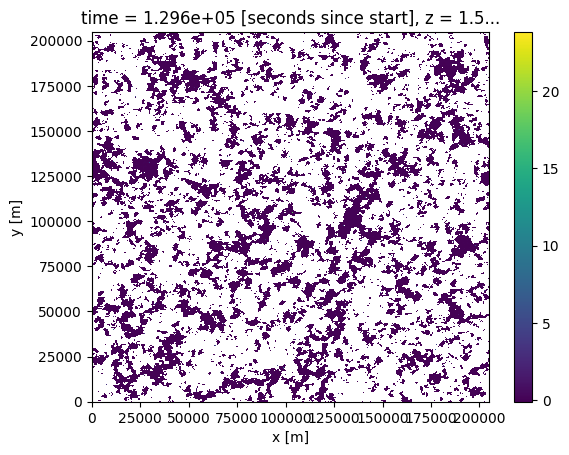

In [12]:
# 1. Mask your data
val_slice = da_b.isel(time=t).sel(z=1500, method="nearest")
mask_slice = ds_shell_mask.isel(time=t).sel(z=1500, method="nearest")
val_masked = val_slice

# 2. Extract bounds
val_min = val_masked.min().compute().item()
val_max = val_masked.max().compute().item()

if val_min == val_max:
    # Disable the default colorbar using add_colorbar=False
    ax = val_masked.plot(
        x="x", 
        y="y", 
        vmin=0, 
        vmax=1,            # Set an arbitrary span so matplotlib can render the solid color
        cmap="viridis", 
        add_colorbar=False 
    )
    
    # Grab the current active plot axes
    current_ax = plt.gca()
    
    # Create a solid color patch representing your uniform value (0.0)
    # 'purple' or '#440154' is typically the 0.0 floor color for the viridis cmap
    zero_patch = mpatches.Patch(color='#440154', label=f'thl = {val_min:.2f}')
    
    # Render the legend box on the plot layout
    current_ax.legend(handles=[zero_patch], loc='upper right', title="θl")
    
else:
    # Normal plotting logic for when there is a valid data gradient
    val_masked.plot(x="x", y="y", vmin=val_min, vmax=val_max, center=False, cmap="viridis")

plt.show()

In [7]:
float(val_masked.min())

-0.10238765917543581

In [8]:
val_min

-0.10238765917543581

In [9]:
val_max

0.05567682281679651

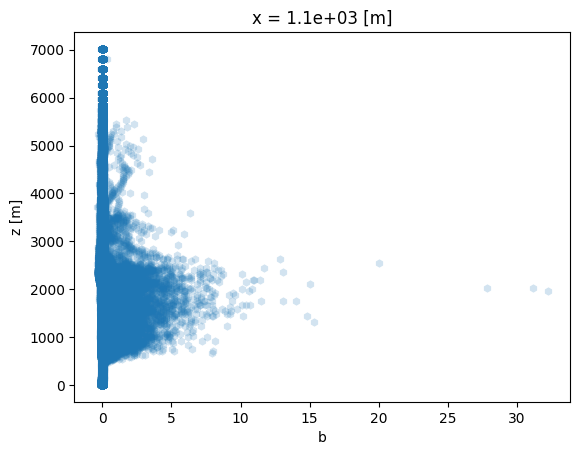

In [11]:
da_b.to_dataset(name="b").sel(x=1000,method="nearest").plot.scatter(x="b",y="z", alpha=0.2, linewidths=0.0, marker='h')

In [ ]:
#w_max = ds_w.w.max(dim=["x","y"])
#w_max.plot(x="time",y="z")